# Student Clustering — Switch4Schools
**Author:** @Ranjeeta | **Module:** `src/profiling/student_clusterer.py` | Epic E2 | IFN735 Team 29

Clusters 11,669 students into behavioural archetypes from emotional check-in history.

## Cluster Archetypes
| Archetype | Profile |
|---|---|
| **Thriving** | Positive dominant, low absence, low tiredness |
| **Disengaged** | High absence OR low intensity OR high tiredness |
| **Emotionally Distressed** | High negative ratio, anxious/sad dominant |
| **Seeking Support** | High chat requests, moderate negative emotions |
| **Stable / Typical** | Balanced across all features |

## What Runs in Each Cell
| Section | Cell | Content |
|---|---|---|
| 0 | Imports | Libraries, constants, `_log()` helper |
| 1 | Load Data | Pipeline → merged_df → student_profiles |
| 2 | Feature Engineering | `build_feature_matrix()` |
| 3 | Optimal K | `find_optimal_k()` → Elbow + Silhouette chart |
| 4 | PCA | `compute_pca()` |
| 5 | Algorithms | K-Means / Agglomerative / GMM / DBSCAN |
| 6 | Metrics + Archetypes | `evaluate_labels()` + `assign_archetypes()` |
| 7a–7g | Visualisations | PCA grid / Silhouette / Radar / Heatmap / 3D / Emotion / Comparison |
| 8 | Export | `student_clusters.json` |
| 9 | Summary | Algorithm comparison table |

## Section 0 — Imports & Setup

In [1]:
%matplotlib inline
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.cm as cm
from typing import Dict, Any, List, Tuple
from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
)

warnings.filterwarnings('ignore')

# ── Project root — notebook lives at project root ─────────────
PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Colour palette & constants ────────────────────────────────
CLUSTER_PALETTE = [
    '#E63946', '#457B9D', '#2A9D8F', '#E9C46A',
    '#F4A261', '#6A4C93', '#8AC926', '#FF595E',
]
ALL_EMOTIONS = ['HAPPY', 'EXCITED', 'CALM', 'SAD', 'ANXIOUS',
                'ANGRY', 'SCARED', 'BORED', 'CONFUSED']
ARCHETYPE_LABELS = {
    'thriving':   'Thriving',
    'disengaged': 'Disengaged',
    'distressed': 'Emotionally Distressed',
    'support':    'Seeking Support',
    'stable':     'Stable / Typical',
}

def _log(msg: str, step: str = 'Clusterer'):
    """Timestamped progress message."""
    ts = time.strftime('%H:%M:%S')
    print(f'[{ts}] [{step}] {msg}', flush=True)

print('Setup complete. PROJECT_ROOT =', PROJECT_ROOT)

Setup complete. PROJECT_ROOT = r:\Phase2\Switchforschool


## Section 1 — Load Data
Runs the full data pipeline to produce `student_profiles`.
This feeds the same data used in `run_pipeline.py`.

> **Note:** Takes ~5 min for 757,112 check-in records. Output: 11,669 student profiles.

In [2]:
from src.data.loader import load_all
from src.data.preprocessor import clean_checkins, merge_datasets
from src.profiling.student_profiler import build_all_student_profiles

_log('Loading all datasets ...')
datasets = load_all()

_log('Cleaning check-ins ...')
clean_df = clean_checkins(datasets['student_checkins'])

_log('Merging datasets ...')
merged_df = merge_datasets(
    clean_df,
    datasets['classes'],
    datasets['sessions'],
    datasets['students'],
)
_log(f'Merged dataset: {len(merged_df):,} rows')

_log('Building per-student profiles (may take a few minutes) ...')
student_profiles = build_all_student_profiles(merged_df)
_log(f'Done — {len(student_profiles):,} student profiles built')

[21:38:16] [Clusterer] Loading all datasets ...
[Loader] Loading student check-ins from R:\Phase2\Switchforschool\datasets\studentCheckIn_cleaned.csv ...
[Loader] Loaded 757,112 check-in records.
[21:38:20] [Clusterer] Cleaning check-ins ...
[Preprocessor] Removed 0 duplicate rows.
[Preprocessor] Clean dataset: 757,112 rows remaining.
[21:38:23] [Clusterer] Merging datasets ...
[Preprocessor] Merging datasets ...
[Preprocessor] Complete relationship table: (757112, 21)
[21:38:25] [Clusterer] Merged dataset: 757,112 rows
[21:38:25] [Clusterer] Building per-student profiles (may take a few minutes) ...
[StudentProfiler] Building per-student emotional profiles ...
[StudentProfiler] 11,669 unique students found.
[StudentProfiler] Done. 11,669 student profiles created.
[21:47:55] [Clusterer] Done — 11,669 student profiles built


## Section 2 — Feature Engineering
Each student is converted into an **8-dimensional numerical vector** from their check-in history.

| Feature | Description |
|---|---|
| `negative_ratio` | Fraction of check-ins with negative emotion (SAD/ANXIOUS/ANGRY/SCARED) |
| `avg_intensity` | Mean emotion intensity (0–1 scale) |
| `avg_tiredness` | Mean tiredness (1–5 scale) |
| `absence_rate` | Fraction of sessions marked absent |
| `chat_requests_norm` | Chat requests ÷ total check-ins |
| `trend_slope` | Linear slope of intensity over time (positive = worsening) |
| `emotion_diversity` | Number of distinct emotions expressed |
| `dominant_neg_flag` | 1 if dominant emotion is negative, else 0 |

All features are **StandardScaler-normalised** before clustering (mean=0, std=1).

In [3]:
def build_feature_matrix(
    student_profiles: Dict[str, Dict],
) -> Tuple[pd.DataFrame, np.ndarray, StandardScaler]:
    rows = []
    for sid, profile in student_profiles.items():
        em    = profile.get('emotions', {})
        wl    = profile.get('wellness_indicators', {})
        tr    = profile.get('trend_analysis', {})
        total = max(profile.get('total_checkins', 1), 1)

        neg_ratio    = em.get('negative_ratio', 0.0)
        avg_int      = em.get('avg_intensity',  0.5)
        avg_tired    = wl.get('avg_tiredness',  3.0)
        absence      = wl.get('absence_rate',   0.0)
        chat_norm    = wl.get('chat_requests',  0) / total
        slope        = tr.get('slope', 0.0) if tr.get('slope') is not None else 0.0
        dom_emotion  = em.get('dominant_emotion', 'HAPPY')
        emotion_counts = em.get('emotion_counts', {})
        diversity    = len(emotion_counts)
        dom_neg_flag = 1 if dom_emotion in {'SAD', 'ANXIOUS', 'ANGRY', 'SCARED'} else 0

        rows.append({
            'student_id':         sid,
            'negative_ratio':     neg_ratio,
            'avg_intensity':      avg_int,
            'avg_tiredness':      avg_tired,
            'absence_rate':       absence,
            'chat_requests_norm': chat_norm,
            'trend_slope':        slope,
            'emotion_diversity':  diversity,
            'dominant_neg_flag':  dom_neg_flag,
        })

    feature_df  = pd.DataFrame(rows).set_index('student_id')
    feature_cols = list(feature_df.columns)
    feature_df[feature_cols] = feature_df[feature_cols].fillna(0)

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(feature_df[feature_cols])
    _log(f'Feature matrix: {X_scaled.shape[0]:,} students x {X_scaled.shape[1]} features')
    return feature_df, X_scaled, scaler


feature_df, X_scaled, scaler = build_feature_matrix(student_profiles)
feature_df.describe()

[21:47:56] [Clusterer] Feature matrix: 11,669 students x 8 features


,negative_ratio,avg_intensity,avg_tiredness,absence_rate,chat_requests_norm,trend_slope,emotion_diversity,dominant_neg_flag
count,11669.000000,11669.000000,11669.000000,11669.000000,11669.0,11669.000000,11669.000000,11669.000000
mean,0.145512,0.681934,3.940335,0.036011,0.0,-0.000327,4.413574,0.054075
std,0.189637,0.244890,0.842867,0.080849,0.0,0.011263,1.668131,0.226175
min,0.000000,0.000000,0.000000,0.000000,0.0,-0.235000,1.000000,0.000000
25%,0.009000,0.488000,3.464000,0.000000,0.0,-0.002820,3.000000,0.000000
50%,0.066000,0.685000,4.034000,0.000000,0.0,0.000000,4.000000,0.000000
75%,0.213000,0.923000,4.632000,0.045000,0.0,0.001160,6.000000,0.000000
max,1.000000,1.000000,5.000000,1.000000,0.0,0.318000,7.000000,1.000000


## Section 3 — Optimal K Selection
Tests K-Means for **K = 2 to 9** and selects the K with the best **Silhouette Score**.

- **Elbow curve** (left) — inertia drops sharply then flattens; the bend is the best K
- **Silhouette score** (right) — higher means clusters are well-separated from each other
- The highlighted bar / dashed line marks the recommended K

[21:47:56] [Clusterer] Searching for optimal K — testing K=2 to K=9 ...
[21:48:00] [K-Search]   K= 2  inertia=62,833  silhouette=0.5587
[21:48:02] [K-Search]   K= 3  inertia=48,458  silhouette=0.2992
[21:48:04] [K-Search]   K= 4  inertia=42,071  silhouette=0.3065
[21:48:06] [K-Search]   K= 5  inertia=36,713  silhouette=0.2819
[21:48:08] [K-Search]   K= 6  inertia=32,373  silhouette=0.2891
[21:48:10] [K-Search]   K= 7  inertia=29,394  silhouette=0.2526
[21:48:12] [K-Search]   K= 8  inertia=27,616  silhouette=0.2580
[21:48:14] [K-Search]   K= 9  inertia=26,088  silhouette=0.2363
[21:48:14] [Clusterer] Best K selected: 2 (highest silhouette)


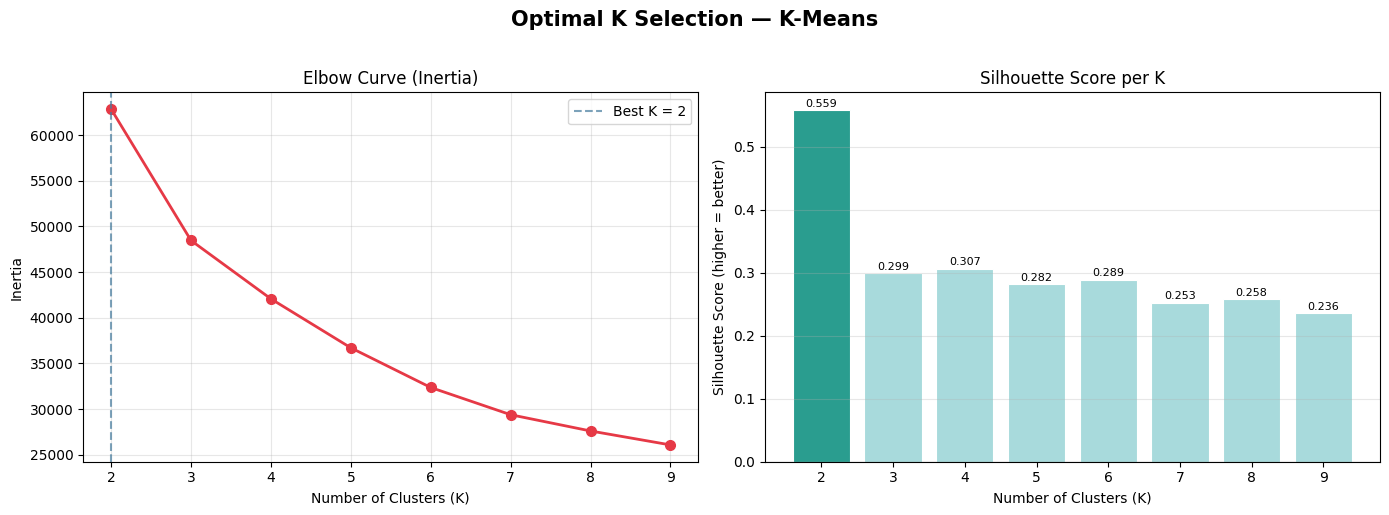

Selected K = 2


In [4]:
def find_optimal_k(
    X_scaled: np.ndarray,
    k_range: range = range(2, 11),
    output_dir: str = OUTPUT_DIR,
) -> int:
    _log('Searching for optimal K — testing K=2 to K=9 ...')
    inertias, silhouettes = [], []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        sil = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else 0.0
        silhouettes.append(sil)
        _log(f'  K={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}', step='K-Search')

    best_k = list(k_range)[int(np.argmax(silhouettes))]
    _log(f'Best K selected: {best_k} (highest silhouette)')

    ks = list(k_range)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Optimal K Selection — K-Means', fontsize=15, fontweight='bold', y=1.02)

    ax1.plot(ks, inertias, 'o-', color='#E63946', linewidth=2, markersize=7)
    ax1.axvline(best_k, color='#457B9D', linestyle='--', alpha=0.7, label=f'Best K = {best_k}')
    ax1.set_title('Elbow Curve (Inertia)')
    ax1.set_xlabel('Number of Clusters (K)'); ax1.set_ylabel('Inertia')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    bar_colors = ['#2A9D8F' if k == best_k else '#A8DADC' for k in ks]
    ax2.bar(ks, silhouettes, color=bar_colors, edgecolor='white', linewidth=0.8)
    ax2.axhline(0, color='gray', linewidth=0.8)
    ax2.set_title('Silhouette Score per K')
    ax2.set_xlabel('Number of Clusters (K)'); ax2.set_ylabel('Silhouette Score (higher = better)')
    ax2.set_xticks(ks)
    for k, s in zip(ks, silhouettes):
        ax2.text(k, s + 0.002, f'{s:.3f}', ha='center', va='bottom', fontsize=8)
    ax2.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    path = os.path.join(output_dir, 'cluster_optimal_k.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    return best_k


best_k = find_optimal_k(X_scaled, k_range=range(2, 10), output_dir=OUTPUT_DIR)
print(f'Selected K = {best_k}')

## Section 4 — PCA Projection
Reduces 8 features → 2 principal components **for visualisation only**.
Clustering itself always runs on the full 8-dimensional space.

> PC1 + PC2 together explain ~53% of variance — enough to see meaningful separation.

In [5]:
def compute_pca(X_scaled: np.ndarray) -> Tuple[np.ndarray, PCA]:
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    var = pca.explained_variance_ratio_
    _log(f'PCA 2D projection done — variance explained: PC1={var[0]:.1%}, PC2={var[1]:.1%}')
    return X_pca, pca


X_pca, pca = compute_pca(X_scaled)

[21:48:15] [Clusterer] PCA 2D projection done — variance explained: PC1=35.4%, PC2=17.6%


## Section 5 — Clustering Algorithms
Four algorithms are run and compared:

| Algorithm | Mechanism | Strength |
|---|---|---|
| **K-Means** | Assigns to nearest centroid, iterates | Fast, interpretable |
| **Agglomerative** | Merges closest pairs (Ward linkage) | Handles unequal cluster sizes |
| **GMM** | Fits Gaussian distributions — soft membership | Overlapping clusters |
| **DBSCAN** | Groups dense regions, marks outliers as noise | Finds outlier students automatically |

In [6]:
def run_kmeans(X_scaled: np.ndarray, k: int) -> np.ndarray:
    _log(f'Running K-Means (k={k}) ...')
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    return km.fit_predict(X_scaled)


def run_dbscan(X_scaled: np.ndarray, eps: float = 1.2, min_samples: int = 10) -> np.ndarray:
    _log(f'Running DBSCAN (eps={eps}, min_samples={min_samples}) ...')
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    n_noise    = int((labels == -1).sum())
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    _log(f'DBSCAN done -> {n_clusters} clusters, {n_noise:,} noise/outlier points')
    return labels


def run_agglomerative(X_scaled: np.ndarray, k: int) -> np.ndarray:
    _log(f'Running Agglomerative / Hierarchical Clustering (k={k}, linkage=ward) ...')
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    return agg.fit_predict(X_scaled)


def run_gmm(X_scaled: np.ndarray, k: int) -> np.ndarray:
    _log(f'Running Gaussian Mixture Model (k={k}) ...')
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    return gmm.fit_predict(X_scaled)


# Run all 4
km_labels  = run_kmeans(X_scaled, best_k)
agg_labels = run_agglomerative(X_scaled, best_k)
gmm_labels = run_gmm(X_scaled, best_k)
db_labels  = run_dbscan(X_scaled)
print('All 4 algorithms complete.')

[21:48:15] [Clusterer] Running K-Means (k=2) ...


[21:48:15] [Clusterer] Running Agglomerative / Hierarchical Clustering (k=2, linkage=ward) ...
[21:48:20] [Clusterer] Running Gaussian Mixture Model (k=2) ...
[21:48:20] [Clusterer] Running DBSCAN (eps=1.2, min_samples=10) ...
[21:48:23] [Clusterer] DBSCAN done -> 5 clusters, 316 noise/outlier points
All 4 algorithms complete.


## Section 6 — Metrics & Archetype Labelling
### Evaluation Metrics
| Metric | What it measures | Best |
|---|---|---|
| **Silhouette Score** | How well each point fits its cluster vs. others (-1 to 1) | Higher |
| **Calinski-Harabász** | Ratio of between- vs. within-cluster variance | Higher |
| **Davies-Bouldin** | Average similarity of each cluster to its most similar cluster | Lower |

### Archetype Rules (applied to cluster centroids)
```
negative_ratio >= 0.35 AND intensity >= 0.4  →  Emotionally Distressed
absence >= 0.10  OR  tiredness >= 4.0  OR  intensity <= 0.35  →  Disengaged
chat_norm >= 0.02  AND  negative >= 0.2  →  Seeking Support
negative <= 0.15  AND  intensity >= 0.5  AND  tiredness <= 3.0  →  Thriving
else  →  Stable / Typical
```

In [7]:
def evaluate_labels(X_scaled: np.ndarray, labels: np.ndarray, name: str) -> Dict[str, Any]:
    """Compute three standard internal clustering quality metrics."""
    valid   = labels[labels != -1]
    X_valid = X_scaled[labels != -1]
    n_clusters = len(set(valid))
    if n_clusters < 2 or len(X_valid) < 2:
        return {'algorithm': name, 'n_clusters': n_clusters,
                'silhouette': None, 'calinski_harabasz': None, 'davies_bouldin': None}
    return {
        'algorithm':          name,
        'n_clusters':         n_clusters,
        'silhouette':         round(float(silhouette_score(X_valid, valid)),       4),
        'calinski_harabasz':  round(float(calinski_harabasz_score(X_valid, valid)),2),
        'davies_bouldin':     round(float(davies_bouldin_score(X_valid, valid)),   4),
    }


def assign_archetypes(
    feature_df: pd.DataFrame,
    labels: np.ndarray,
) -> Dict[int, str]:
    """Assign human-readable archetype labels based on cluster centroids."""
    feature_df = feature_df.copy()
    feature_df['cluster'] = labels
    centroids = feature_df.groupby('cluster').mean(numeric_only=True)
    archetype_map: Dict[int, str] = {}
    for cid, row in centroids.iterrows():
        if cid == -1:
            archetype_map[cid] = 'Noise / Outlier'; continue
        neg       = row.get('negative_ratio', 0)
        absc      = row.get('absence_rate', 0)
        tired     = row.get('avg_tiredness', 3)
        chat      = row.get('chat_requests_norm', 0)
        intensity = row.get('avg_intensity', 0.5)
        if   neg >= 0.35 and intensity >= 0.4:                   archetype_map[cid] = 'Emotionally Distressed'
        elif absc >= 0.10 or tired >= 4.0 or intensity <= 0.35:  archetype_map[cid] = 'Disengaged'
        elif chat >= 0.02 and neg >= 0.2:                        archetype_map[cid] = 'Seeking Support'
        elif neg <= 0.15 and intensity >= 0.5 and tired <= 3.0:  archetype_map[cid] = 'Thriving'
        else:                                                     archetype_map[cid] = 'Stable / Typical'
    return archetype_map


# Evaluate + label all 4 algorithms
all_results = {}
for algo_name, labels in [
    ('K-Means',       km_labels),
    ('Agglomerative', agg_labels),
    ('GMM',           gmm_labels),
    ('DBSCAN',        db_labels),
]:
    arch    = assign_archetypes(feature_df, labels)
    metrics = evaluate_labels(X_scaled, labels, algo_name)
    all_results[algo_name] = {'labels': labels, 'archetypes': arch, 'metrics': metrics}
    _log(f'{algo_name:<18} -> {metrics["n_clusters"]} clusters  '
         f'silhouette={metrics["silhouette"]}', step='Eval')

print('Metrics computed for all algorithms.')

[21:48:25] [Eval] K-Means            -> 2 clusters  silhouette=0.5587
[21:48:27] [Eval] Agglomerative      -> 2 clusters  silhouette=0.5565
[21:48:29] [Eval] GMM                -> 2 clusters  silhouette=0.5571
[21:48:32] [Eval] DBSCAN             -> 5 clusters  silhouette=0.5478
Metrics computed for all algorithms.


## Section 7 — Visualisations
### 7a. PCA Scatter — All 4 Algorithms
2×2 grid showing student clusters projected onto 2 principal components.
Each colour is a cluster archetype. Compare how each algorithm carves up the space.

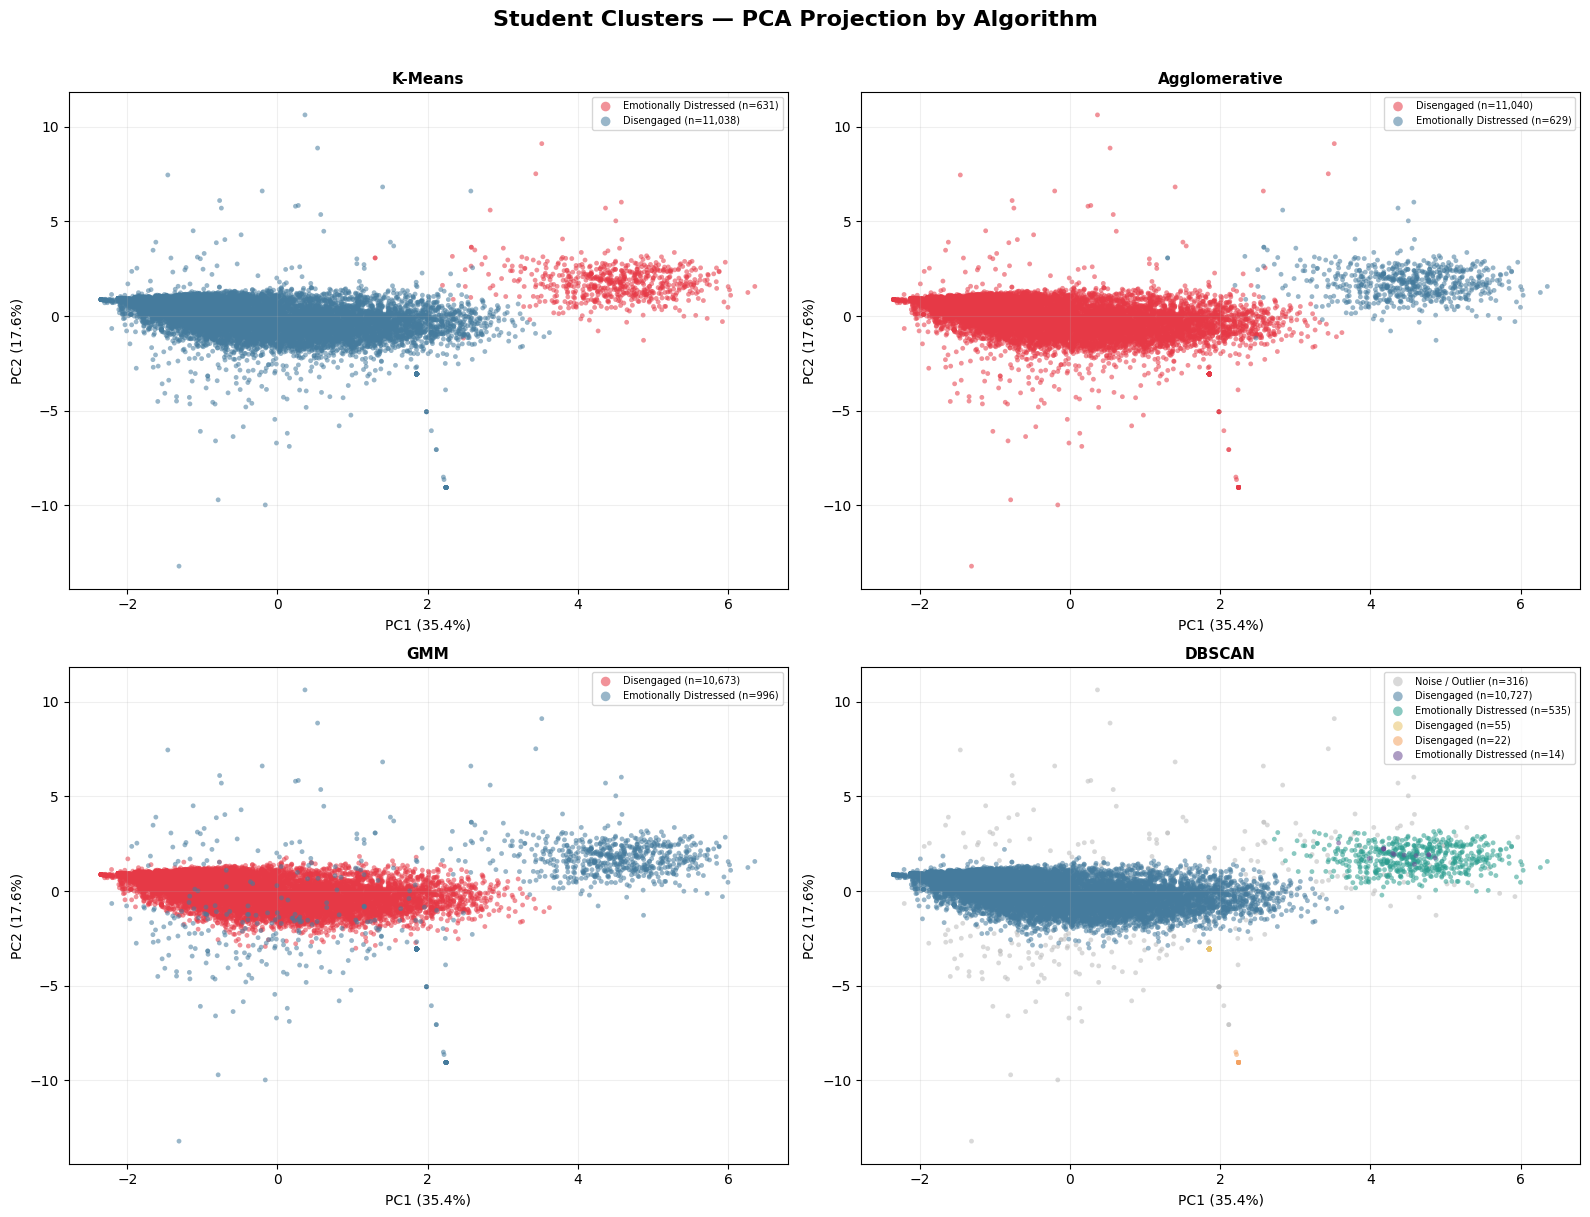

In [8]:
def _scatter_pca(ax, X_pca, labels, title, archetype_map, pca):
    """Draw a 2-D PCA scatter coloured by cluster on the given Axes."""
    unique_labels = sorted(set(labels))
    for i, cid in enumerate(unique_labels):
        mask  = labels == cid
        color = '#BBBBBB' if cid == -1 else CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)]
        lname = archetype_map.get(cid, f'Cluster {cid}')
        cnt   = int(mask.sum())
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=color, alpha=0.55, s=12, label=f'{lname} (n={cnt:,})', edgecolors='none',
        )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.legend(fontsize=7, markerscale=2, loc='upper right')
    ax.grid(True, alpha=0.2)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Student Clusters — PCA Projection by Algorithm', fontsize=16, fontweight='bold', y=1.01)
for ax, (algo_name, res) in zip(axes.flat, all_results.items()):
    _scatter_pca(ax, X_pca, res['labels'], algo_name, res['archetypes'], pca)
for ax in axes.flat[len(all_results):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cluster_all_algorithms_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7b. Per-Sample Silhouette Plots
One chart per algorithm. Each band is a cluster — width = how well each student fits their cluster.
- Red dashed line = mean silhouette score
- Negative values = students that might belong to a different cluster

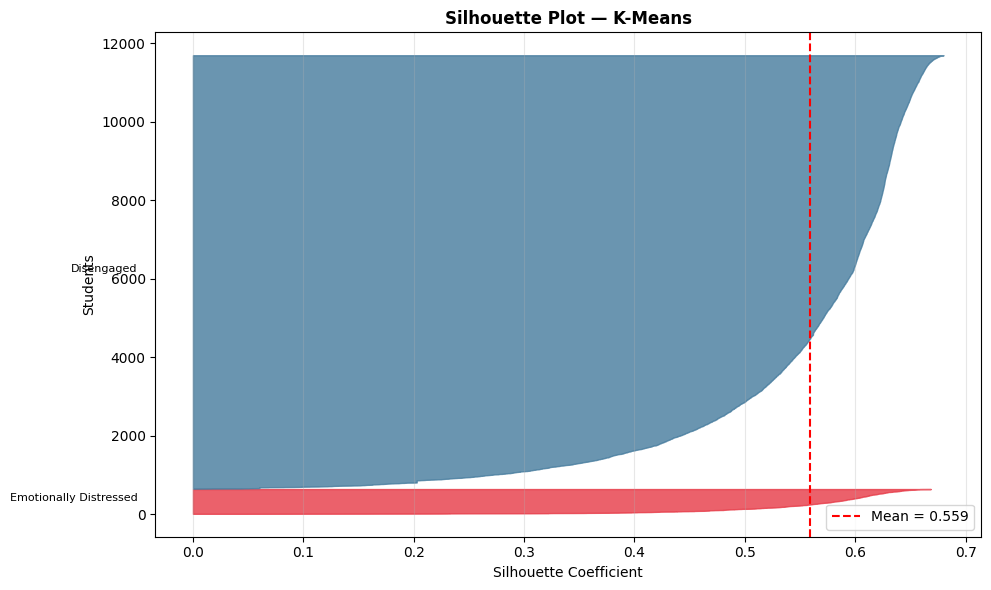

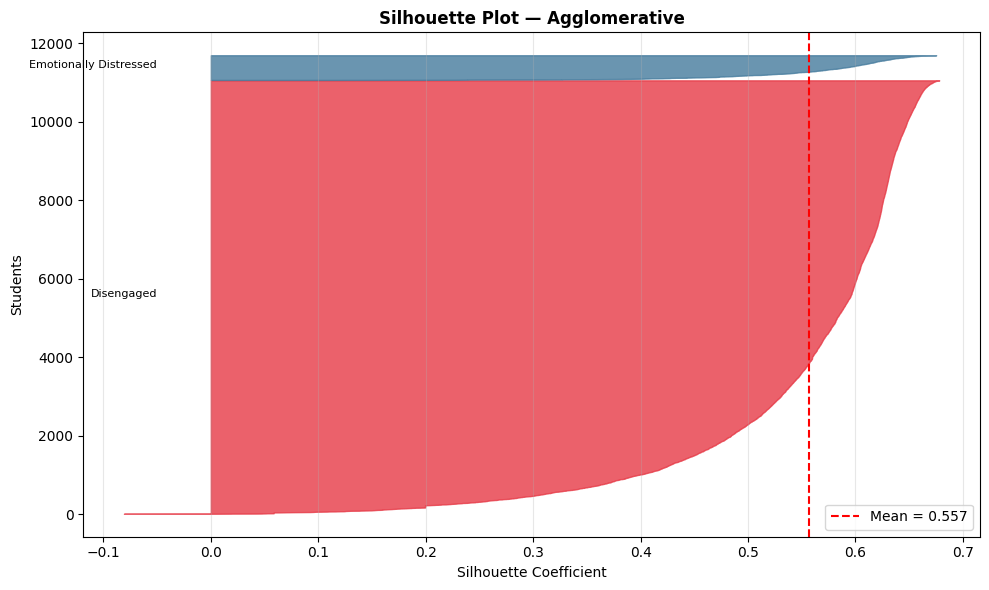

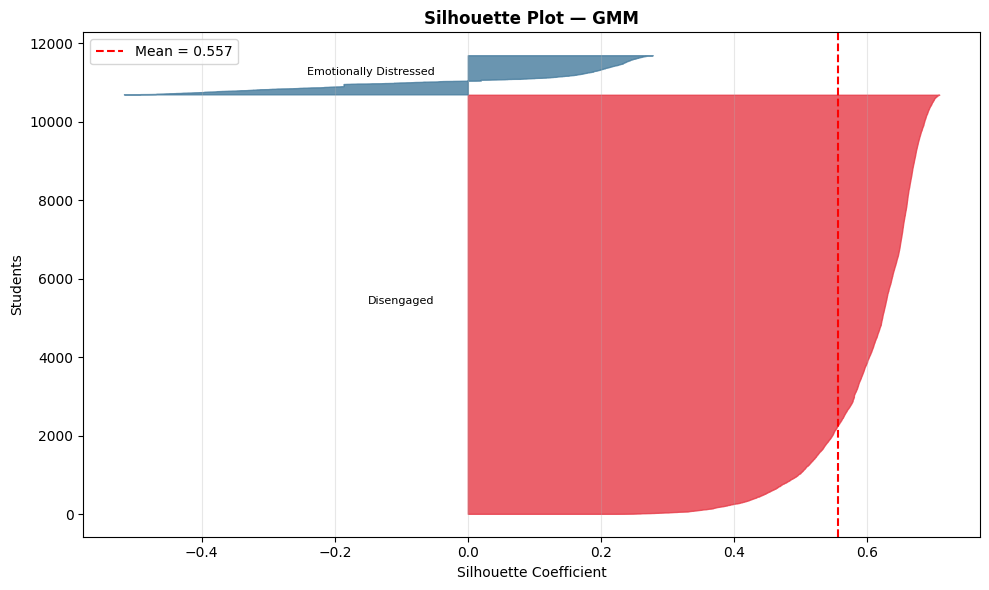

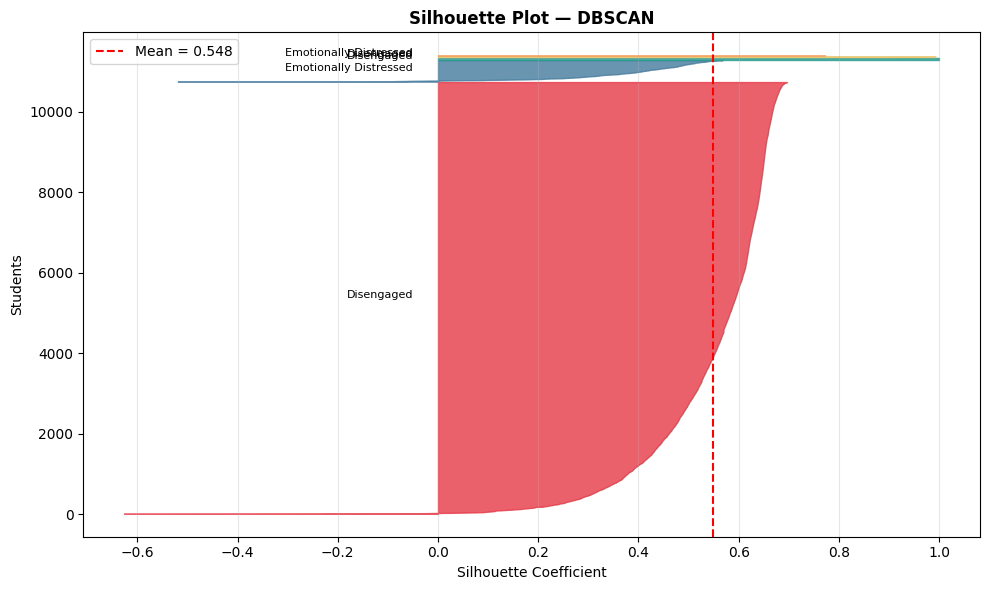

In [9]:
def plot_silhouette_samples(
    X_scaled: np.ndarray,
    labels: np.ndarray,
    algo_name: str,
    archetype_map: Dict[int, str],
    output_dir: str = OUTPUT_DIR,
):
    valid_mask = labels != -1
    X_v = X_scaled[valid_mask]
    L_v = labels[valid_mask]
    if len(set(L_v)) < 2:
        return
    sample_sils = silhouette_samples(X_v, L_v)
    fig, ax = plt.subplots(figsize=(10, 6))
    y_lower = 10
    for cid in sorted(set(L_v)):
        vals    = np.sort(sample_sils[L_v == cid])
        y_upper = y_lower + len(vals)
        color   = CLUSTER_PALETTE[cid % len(CLUSTER_PALETTE)]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                         facecolor=color, edgecolor=color, alpha=0.8)
        ax.text(-0.05, y_lower + len(vals) / 2,
                f'{archetype_map.get(cid, cid)}', ha='right', fontsize=8)
        y_lower = y_upper + 10
    mean_sil = float(silhouette_score(X_v, L_v))
    ax.axvline(mean_sil, color='red', linestyle='--', label=f'Mean = {mean_sil:.3f}')
    ax.set_title(f'Silhouette Plot — {algo_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient'); ax.set_ylabel('Students')
    ax.legend(); ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    safe = algo_name.lower().replace(' ', '_').replace('-', '_')
    path = os.path.join(output_dir, f'cluster_silhouette_{safe}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()


for algo_name, res in all_results.items():
    plot_silhouette_samples(X_scaled, res['labels'], algo_name, res['archetypes'])

### 7c. Cluster Profiles — Radar Chart + Centroid Heatmap
- **Radar chart** (left): shape of each cluster's mean feature profile
- **Heatmap** (right): same data as colour matrix — see at a glance which features drive each archetype

> A cluster with large `negative_ratio` + large `avg_tiredness` spokes = **Disengaged**

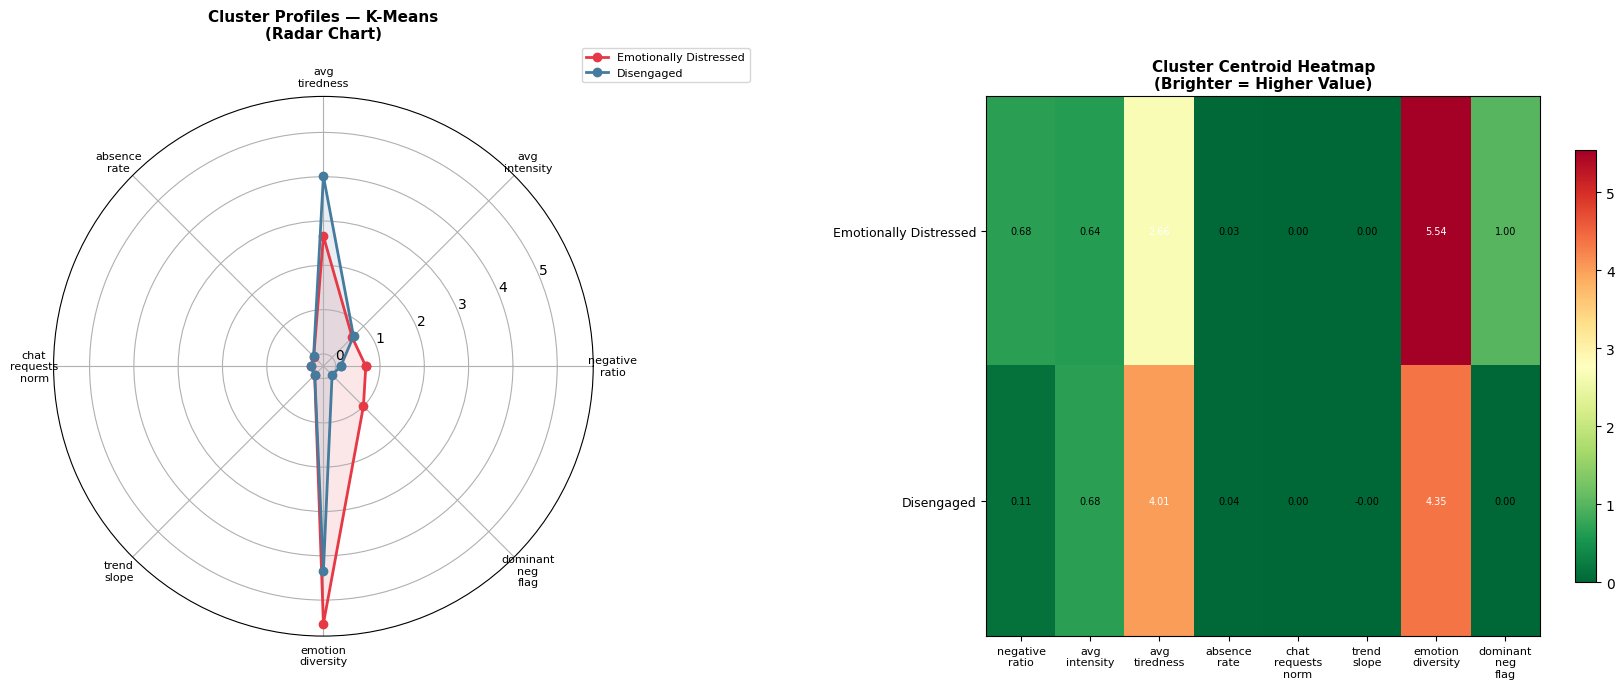

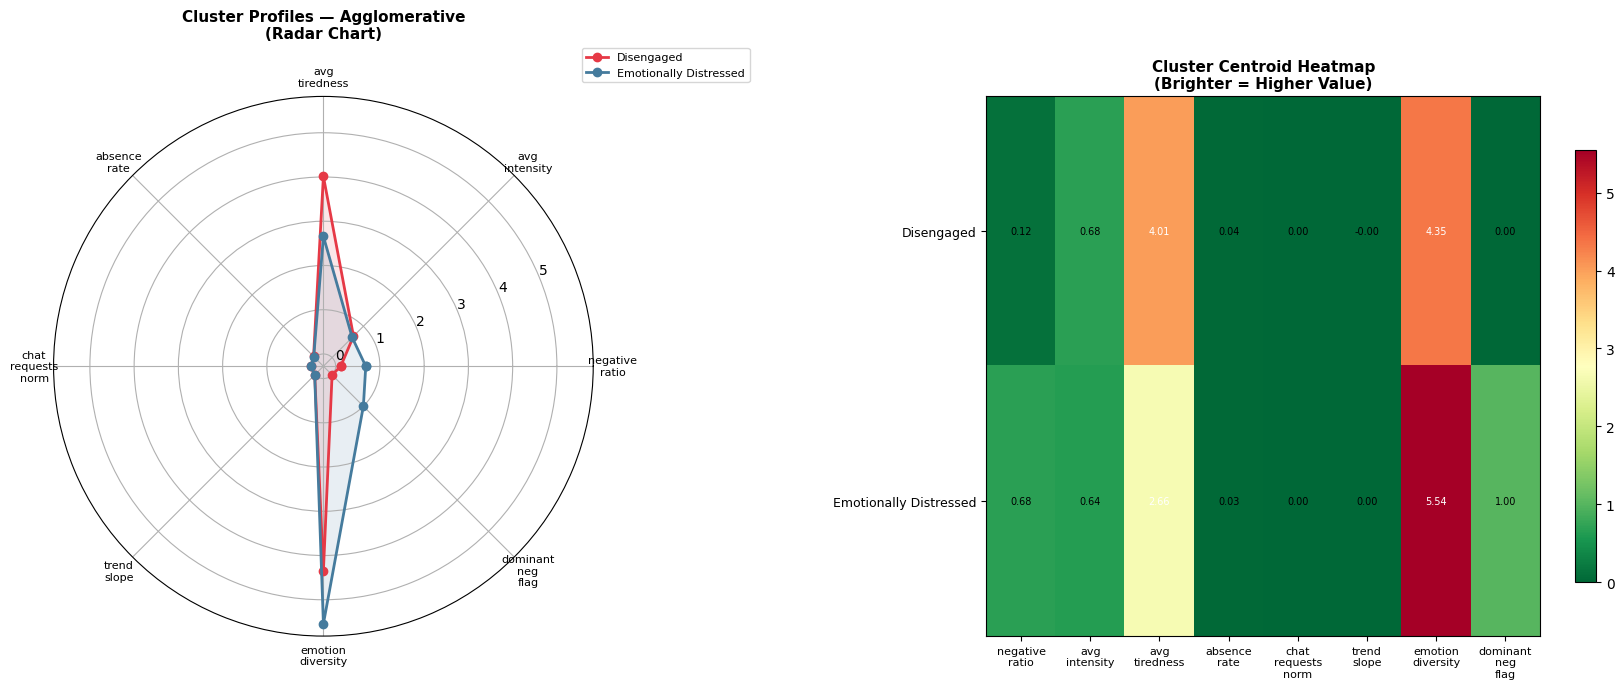

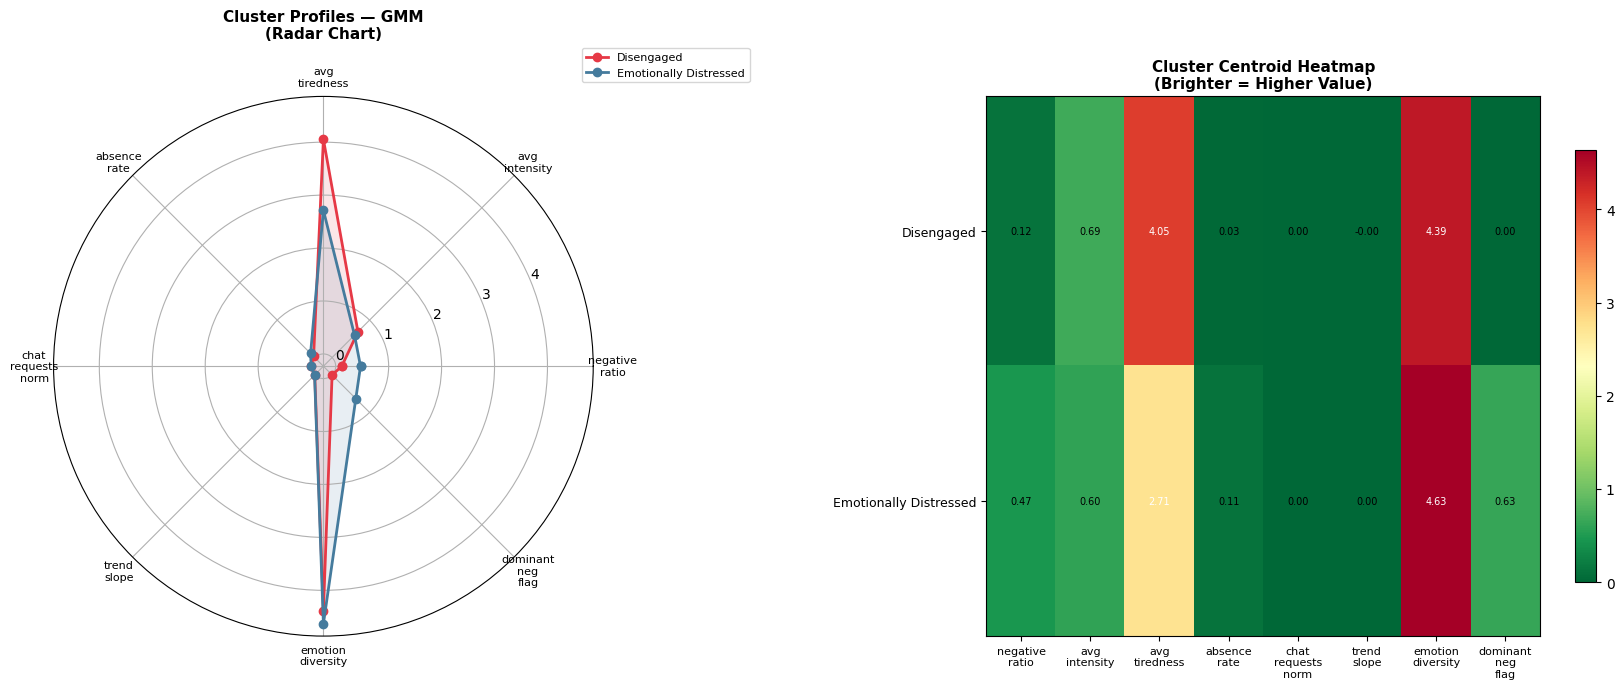

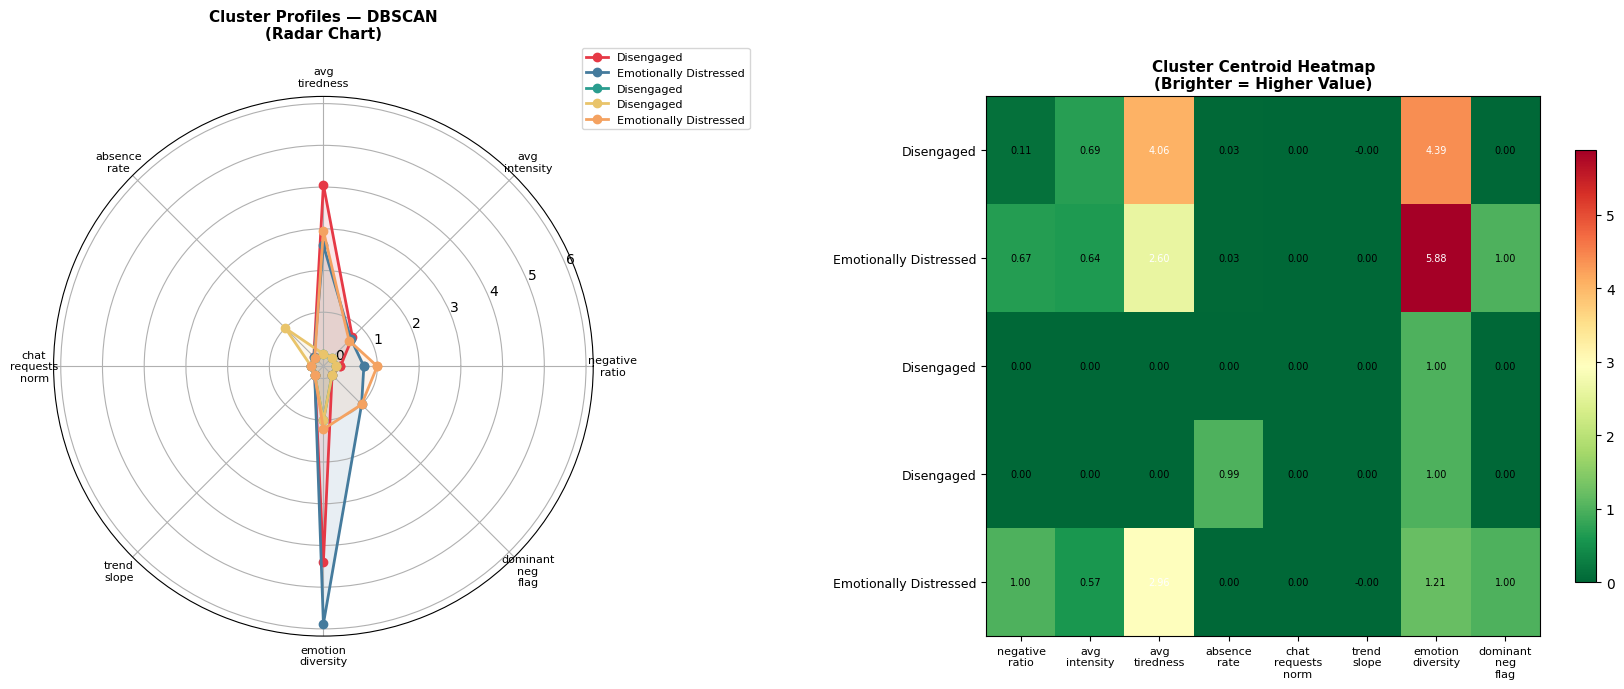

In [10]:
def plot_cluster_profiles(
    feature_df: pd.DataFrame,
    labels: np.ndarray,
    algo_name: str,
    archetype_map: Dict[int, str],
    output_dir: str = OUTPUT_DIR,
):
    df = feature_df.copy()
    df['cluster'] = labels
    df = df[df['cluster'] != -1]
    centroids = df.groupby('cluster').mean(numeric_only=True)
    features  = list(centroids.columns)
    N      = len(features)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(18, 7))
    gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.2, 1])
    ax_radar = fig.add_subplot(gs[0], polar=True)
    ax_heat  = fig.add_subplot(gs[1])

    for cid, row in centroids.iterrows():
        vals  = row[features].tolist()
        vals += vals[:1]
        color = CLUSTER_PALETTE[cid % len(CLUSTER_PALETTE)]
        label = archetype_map.get(cid, f'Cluster {cid}')
        ax_radar.plot(angles, vals, 'o-', linewidth=2, color=color, label=label)
        ax_radar.fill(angles, vals, alpha=0.12, color=color)
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels([f.replace('_', '\n') for f in features], fontsize=8)
    ax_radar.set_title(f'Cluster Profiles — {algo_name}\n(Radar Chart)',
                       fontsize=11, fontweight='bold', pad=20)
    ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

    heat_data = centroids[features].copy()
    heat_data.index = [archetype_map.get(i, f'C{i}') for i in heat_data.index]
    im = ax_heat.imshow(heat_data.values, cmap='RdYlGn_r', aspect='auto')
    ax_heat.set_xticks(range(len(features)))
    ax_heat.set_xticklabels([f.replace('_', '\n') for f in features], fontsize=8)
    ax_heat.set_yticks(range(len(heat_data)))
    ax_heat.set_yticklabels(heat_data.index, fontsize=9)
    ax_heat.set_title('Cluster Centroid Heatmap\n(Brighter = Higher Value)',
                      fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax_heat, shrink=0.8)
    for i in range(heat_data.shape[0]):
        for j in range(heat_data.shape[1]):
            val = heat_data.values[i, j]
            ax_heat.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                         color='white' if abs(val) > heat_data.values.std() else 'black')
    plt.tight_layout()
    safe = algo_name.lower().replace(' ', '_').replace('-', '_')
    path = os.path.join(output_dir, f'cluster_profiles_{safe}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()


for algo_name, res in all_results.items():
    plot_cluster_profiles(feature_df, res['labels'], algo_name, res['archetypes'])

### 7d. Cluster Size Distribution
Bar chart showing how many students fall into each cluster per algorithm.
Very unequal sizes may indicate one algorithm is not well-calibrated for this data.

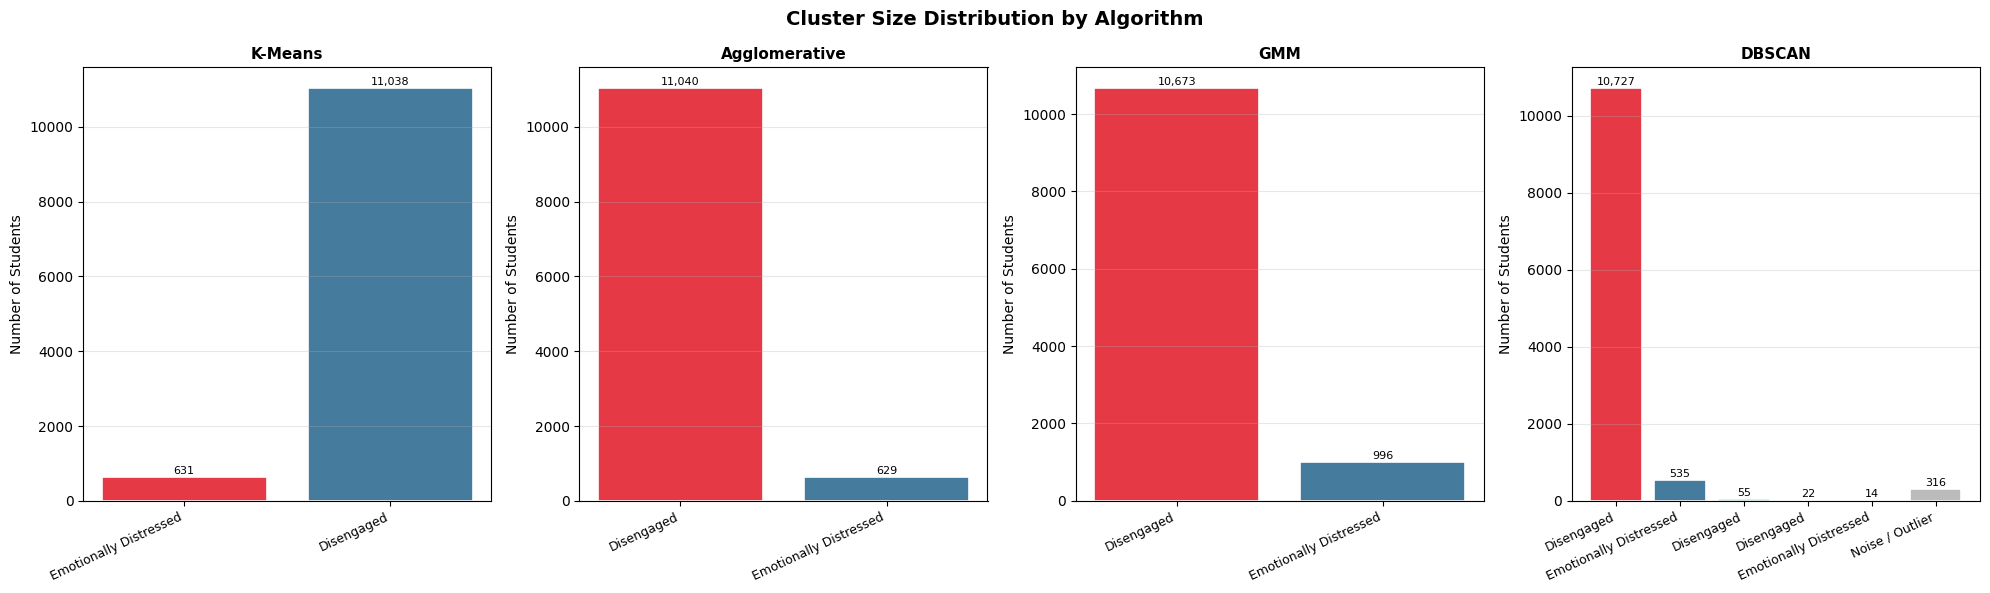

In [11]:
def plot_cluster_size_distribution(
    all_results: Dict[str, Dict],
    output_dir: str = OUTPUT_DIR,
):
    n_algos = len(all_results)
    fig, axes = plt.subplots(1, n_algos, figsize=(5 * n_algos, 6))
    if n_algos == 1:
        axes = [axes]
    fig.suptitle('Cluster Size Distribution by Algorithm', fontsize=14, fontweight='bold')
    for ax, (algo_name, res) in zip(axes, all_results.items()):
        labels = res['labels']
        arch   = res['archetypes']
        counts = Counter(labels)
        sorted_cids = sorted([c for c in counts if c != -1])
        if -1 in counts:
            sorted_cids.append(-1)
        names  = [arch.get(c, f'C{c}') for c in sorted_cids]
        sizes  = [counts[c] for c in sorted_cids]
        colors = [CLUSTER_PALETTE[c % len(CLUSTER_PALETTE)] if c != -1 else '#BBBBBB'
                  for c in sorted_cids]
        bars = ax.bar(range(len(names)), sizes, color=colors, edgecolor='white', linewidth=1.2)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
        ax.set_title(algo_name, fontsize=11, fontweight='bold')
        ax.set_ylabel('Number of Students')
        ax.grid(True, axis='y', alpha=0.3)
        for bar, sz in zip(bars, sizes):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                    f'{sz:,}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    path = os.path.join(output_dir, 'cluster_size_distribution.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()


plot_cluster_size_distribution(all_results)

### 7e. Algorithm Comparison — 3 Metrics
The best algorithm for each metric is highlighted:
- **Teal** = highest Silhouette (best)
- **Gold** = highest Calinski-Harabász (best)
- **Red** = lowest Davies-Bouldin (best)

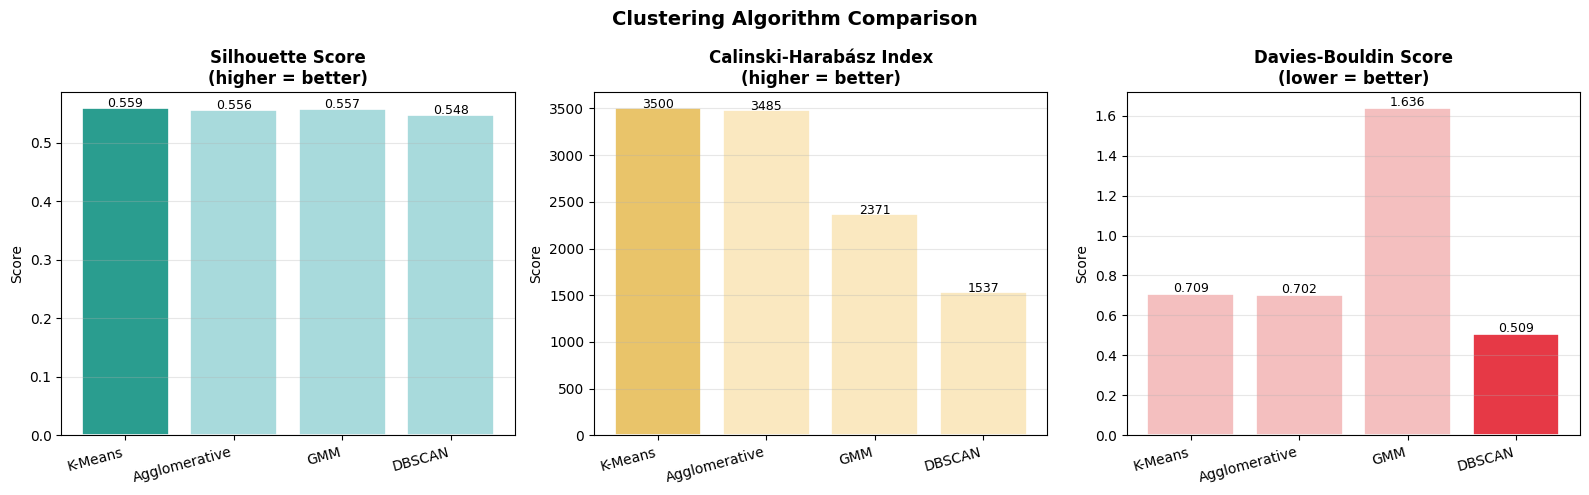

In [12]:
def plot_algorithm_comparison(
    metrics: List[Dict[str, Any]],
    output_dir: str = OUTPUT_DIR,
):
    valid = [m for m in metrics if m['silhouette'] is not None]
    algos = [m['algorithm'] for m in valid]
    sil   = [m['silhouette'] for m in valid]
    ch    = [m['calinski_harabasz'] for m in valid]
    db    = [m['davies_bouldin'] for m in valid]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Clustering Algorithm Comparison', fontsize=14, fontweight='bold')
    x    = np.arange(len(algos))
    bar_kw = dict(edgecolor='white', linewidth=1.2)

    best_sil = np.argmax(sil)
    ax1.bar(x, sil, color=['#2A9D8F' if i == best_sil else '#A8DADC' for i in range(len(algos))], **bar_kw)
    ax1.set_xticks(x); ax1.set_xticklabels(algos, rotation=15, ha='right')
    ax1.set_title('Silhouette Score\n(higher = better)', fontweight='bold')
    ax1.set_ylabel('Score'); ax1.grid(True, axis='y', alpha=0.3)
    for i, v in enumerate(sil):
        ax1.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

    best_ch = np.argmax(ch)
    ax2.bar(x, ch, color=['#E9C46A' if i == best_ch else '#FAE8C0' for i in range(len(algos))], **bar_kw)
    ax2.set_xticks(x); ax2.set_xticklabels(algos, rotation=15, ha='right')
    ax2.set_title('Calinski-Harabász Index\n(higher = better)', fontweight='bold')
    ax2.set_ylabel('Score'); ax2.grid(True, axis='y', alpha=0.3)
    for i, v in enumerate(ch):
        ax2.text(i, v + 1, f'{v:.0f}', ha='center', fontsize=9)

    best_db = np.argmin(db)
    ax3.bar(x, db, color=['#E63946' if i == best_db else '#F4BFBF' for i in range(len(algos))], **bar_kw)
    ax3.set_xticks(x); ax3.set_xticklabels(algos, rotation=15, ha='right')
    ax3.set_title('Davies-Bouldin Score\n(lower = better)', fontweight='bold')
    ax3.set_ylabel('Score'); ax3.grid(True, axis='y', alpha=0.3)
    for i, v in enumerate(db):
        ax3.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

    plt.tight_layout()
    path = os.path.join(output_dir, 'cluster_algorithm_comparison.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()


all_metrics = [r['metrics'] for r in all_results.values()]
plot_algorithm_comparison(all_metrics)

### 7f. Dominant Emotion Breakdown per Cluster
Stacked bar showing what fraction of students in each cluster have each dominant emotion.
This is the key chart that **explains why** a cluster received its archetype label.

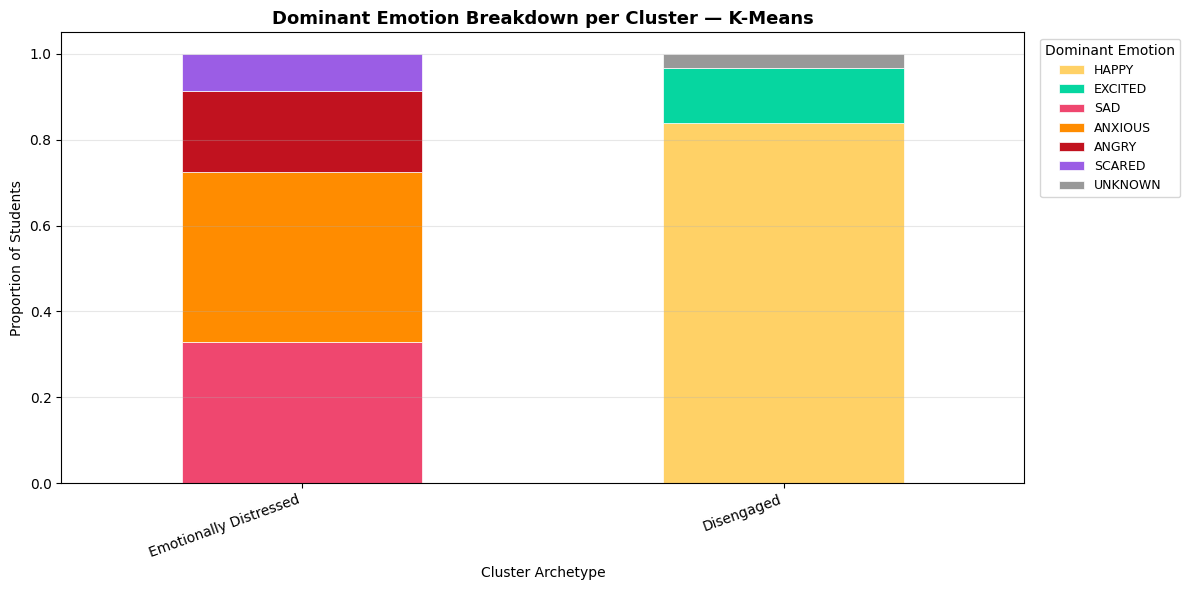

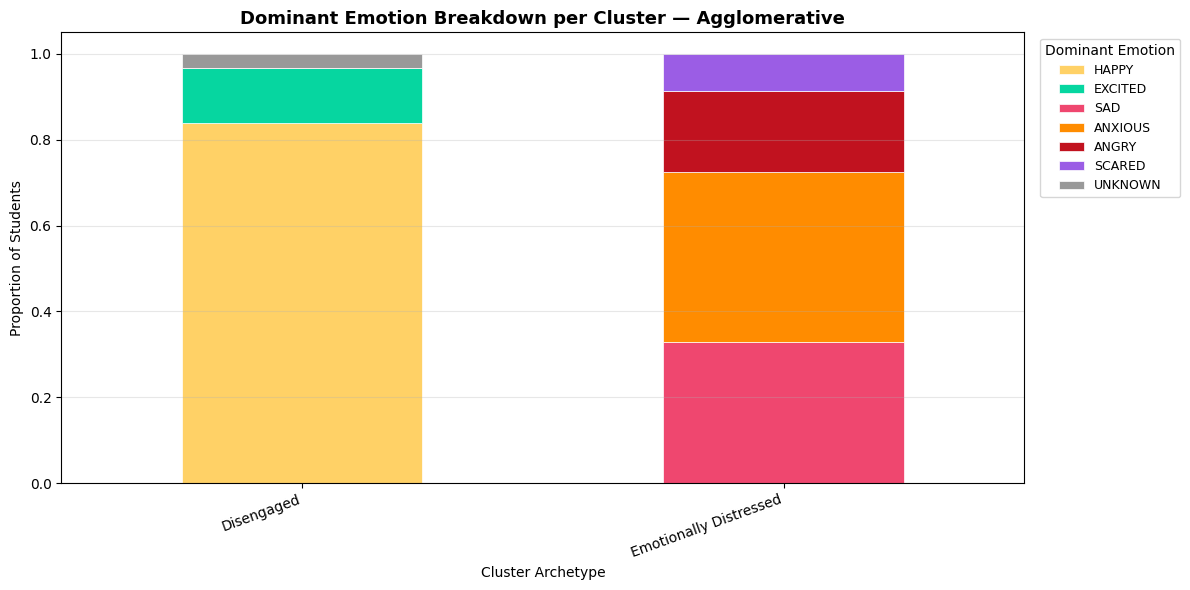

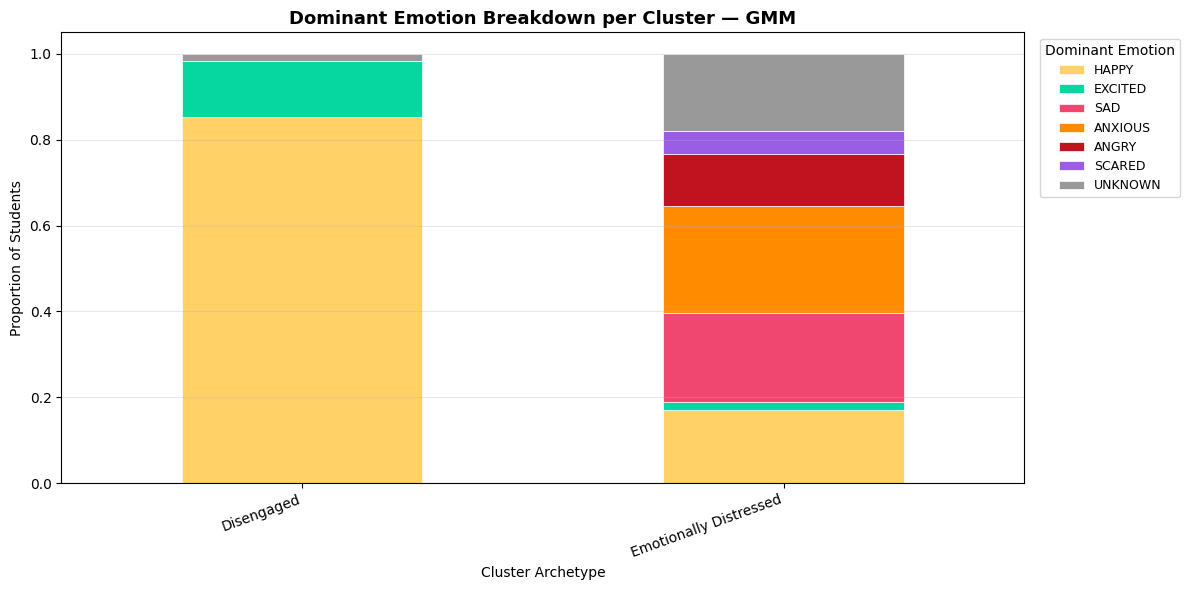

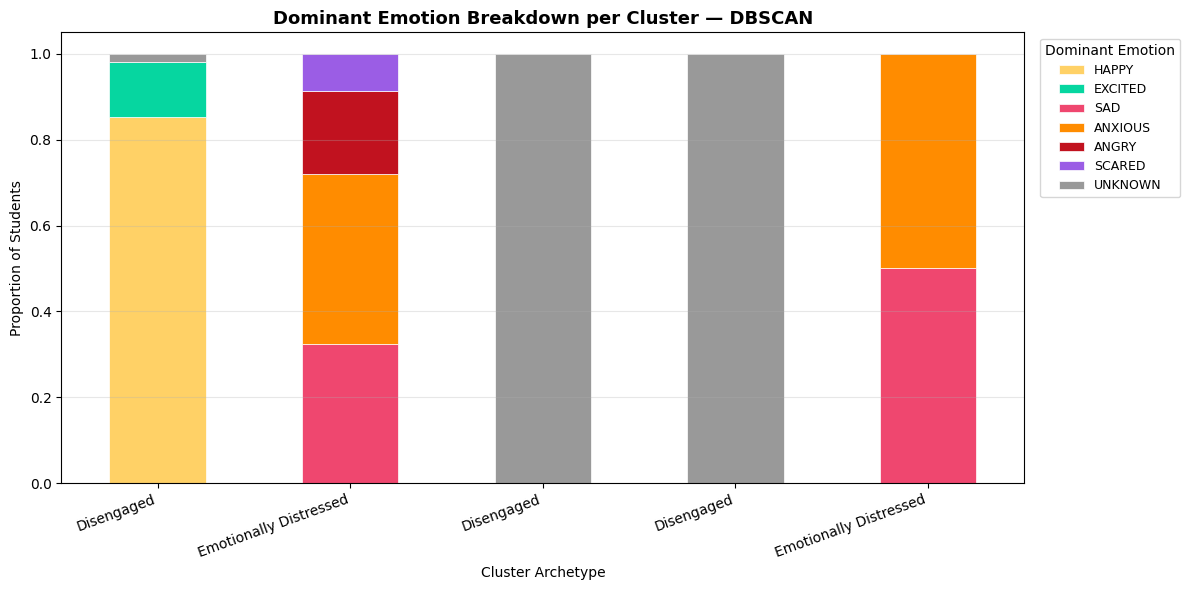

In [13]:
def plot_emotion_breakdown_per_cluster(
    feature_df: pd.DataFrame,
    student_profiles: Dict[str, Dict],
    labels: np.ndarray,
    algo_name: str,
    archetype_map: Dict[int, str],
    output_dir: str = OUTPUT_DIR,
):
    rows = []
    df = feature_df.copy()
    df['cluster'] = labels
    for sid in df.index:
        cid = int(df.loc[sid, 'cluster'])
        if cid == -1:
            continue
        dom = student_profiles[sid].get('emotions', {}).get('dominant_emotion', 'UNKNOWN')
        rows.append({'cluster': cid, 'emotion': dom})
    if not rows:
        return
    emotion_df = pd.DataFrame(rows)
    pivot = emotion_df.groupby(['cluster', 'emotion']).size().unstack(fill_value=0)
    pivot = pivot.div(pivot.sum(axis=1), axis=0)
    pivot.index = [archetype_map.get(i, f'C{i}') for i in pivot.index]
    emotion_colors = {
        'HAPPY':   '#FFD166', 'EXCITED': '#06D6A0', 'CALM':    '#118AB2',
        'SAD':     '#EF476F', 'ANXIOUS': '#FF8C00', 'ANGRY':   '#C1121F',
        'SCARED':  '#9B5DE5', 'BORED':   '#AAAAAA', 'CONFUSED':'#5C677D',
    }
    cols_in_data = [e for e in ALL_EMOTIONS if e in pivot.columns]
    remaining    = [c for c in pivot.columns if c not in cols_in_data]
    pivot = pivot[cols_in_data + remaining]
    colors = [emotion_colors.get(c, '#999999') for c in pivot.columns]
    pivot.plot(kind='bar', stacked=True, color=colors, figsize=(12, 6),
               edgecolor='white', linewidth=0.5)
    plt.title(f'Dominant Emotion Breakdown per Cluster — {algo_name}',
              fontsize=13, fontweight='bold')
    plt.xlabel('Cluster Archetype')
    plt.ylabel('Proportion of Students')
    plt.xticks(rotation=20, ha='right')
    plt.legend(title='Dominant Emotion', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    safe = algo_name.lower().replace(' ', '_').replace('-', '_')
    path = os.path.join(output_dir, f'cluster_emotion_breakdown_{safe}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()


for algo_name, res in all_results.items():
    plot_emotion_breakdown_per_cluster(
        feature_df, student_profiles, res['labels'], algo_name, res['archetypes']
    )

### 7g. 3-D PCA Scatter
Three principal components for extra depth. Shows spatial separation between archetypes.

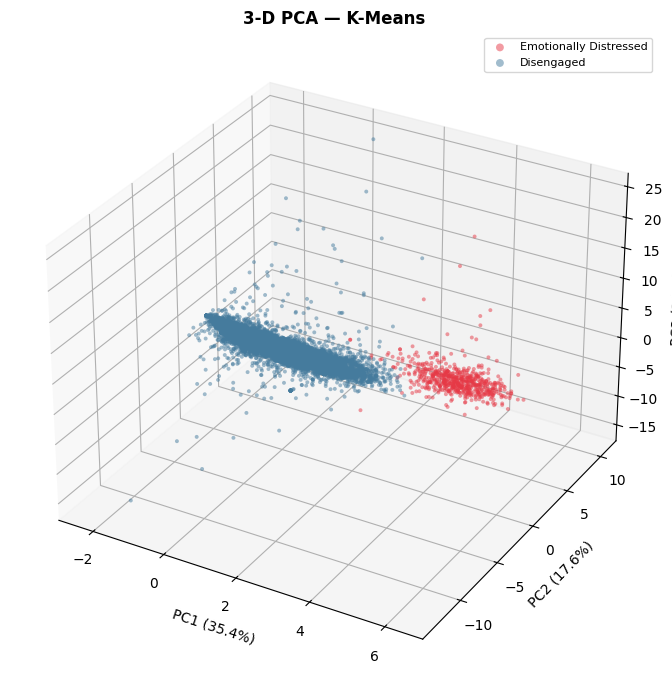

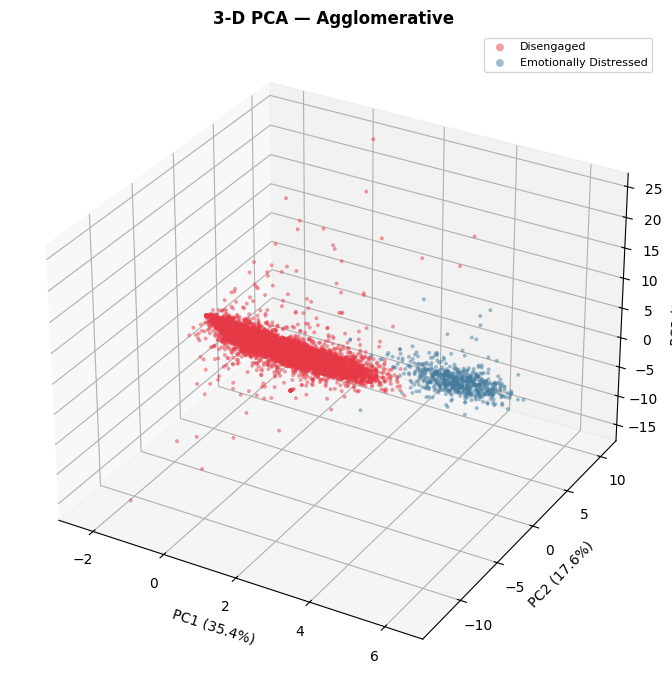

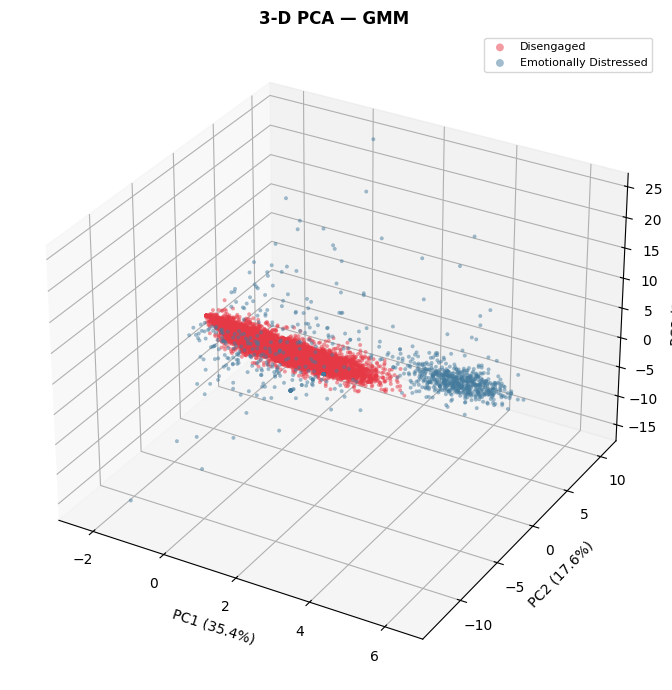

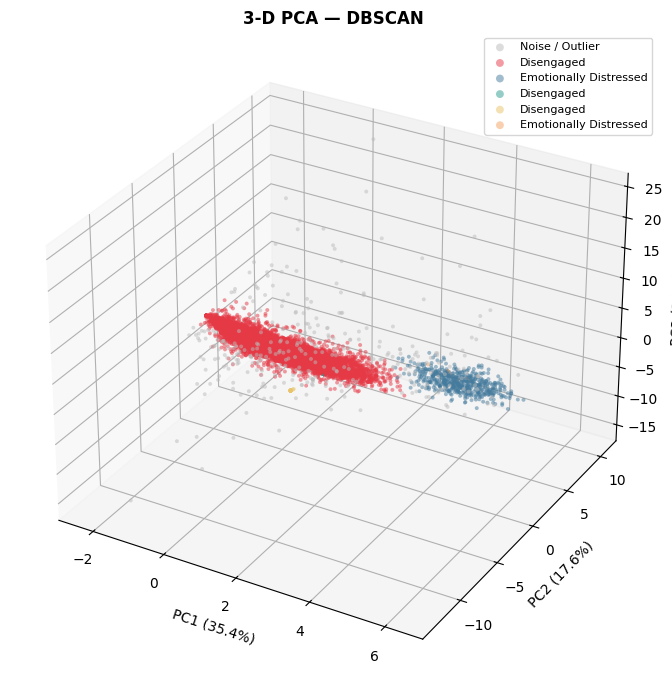

In [14]:
def plot_3d_pca(
    X_scaled: np.ndarray,
    labels: np.ndarray,
    algo_name: str,
    archetype_map: Dict[int, str],
    output_dir: str = OUTPUT_DIR,
):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    pca3 = PCA(n_components=3, random_state=42)
    X3   = pca3.fit_transform(X_scaled)
    fig  = plt.figure(figsize=(10, 7))
    ax   = fig.add_subplot(111, projection='3d')
    for cid in sorted(set(labels)):
        mask  = labels == cid
        color = '#BBBBBB' if cid == -1 else CLUSTER_PALETTE[cid % len(CLUSTER_PALETTE)]
        name  = archetype_map.get(cid, f'Cluster {cid}')
        ax.scatter(X3[mask, 0], X3[mask, 1], X3[mask, 2],
                   c=color, alpha=0.5, s=8, label=name, edgecolors='none')
    var = pca3.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({var[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var[1]:.1%})')
    ax.set_zlabel(f'PC3 ({var[2]:.1%})')
    ax.set_title(f'3-D PCA — {algo_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)
    plt.tight_layout()
    safe = algo_name.lower().replace(' ', '_').replace('-', '_')
    path = os.path.join(output_dir, f'cluster_3d_pca_{safe}.png')
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show()


for algo_name, res in all_results.items():
    plot_3d_pca(X_scaled, res['labels'], algo_name, res['archetypes'])

## Section 8 — Export Results
Saves student assignments + cluster summaries to `outputs/student_clusters.json`.
This file is read by the Streamlit dashboard and downstream modules.

In [15]:
def build_cluster_output(
    feature_df: pd.DataFrame,
    labels: np.ndarray,
    archetype_map: Dict[int, str],
    metrics: Dict[str, Any],
    algo_name: str,
) -> Dict[str, Any]:
    student_assignments = {}
    for sid, cid in zip(feature_df.index, labels):
        student_assignments[str(sid)] = {
            'cluster_id': int(cid),
            'archetype':  archetype_map.get(int(cid), 'Unknown'),
        }
    cluster_summaries = {}
    tmp = feature_df.copy()
    tmp['cluster'] = labels
    for cid, grp in tmp.groupby('cluster'):
        cluster_summaries[str(int(cid))] = {
            'archetype':           archetype_map.get(int(cid), 'Unknown'),
            'n_students':          int(len(grp)),
            'mean_negative_ratio': round(float(grp['negative_ratio'].mean()), 3),
            'mean_avg_intensity':  round(float(grp['avg_intensity'].mean()),  3),
            'mean_avg_tiredness':  round(float(grp['avg_tiredness'].mean()),  3),
            'mean_absence_rate':   round(float(grp['absence_rate'].mean()),   3),
        }
    return {
        'algorithm':           algo_name,
        'metrics':             metrics,
        'cluster_summaries':   cluster_summaries,
        'student_assignments': student_assignments,
    }


BEST_ALGO = 'K-Means'   # change if another algorithm scored better above
best = all_results[BEST_ALGO]
result = build_cluster_output(
    feature_df, best['labels'], best['archetypes'], best['metrics'], BEST_ALGO
)
result['metrics_comparison'] = all_metrics
result['best_k'] = best_k

out_path = os.path.join(OUTPUT_DIR, 'student_clusters.json')
with open(out_path, 'w') as f:
    json.dump(result, f, indent=2, default=str)
print(f'Saved -> {out_path}')
print(f'Students assigned: {len(result["student_assignments"]):,}')

Saved -> r:\Phase2\Switchforschool\outputs\student_clusters.json
Students assigned: 11,669


## Section 9 — Summary
Final comparison table and cluster breakdown for the best algorithm.

In [16]:
print('\n' + '─'*62)
print(f'  {"Algorithm":<20} {"K":>3}  {"Silhouette":>10}  {"C-H Index":>12}  {"D-B":>8}')
print('─'*62)
for m in all_metrics:
    sil = f"{m['silhouette']:.4f}" if m['silhouette'] is not None else '  N/A  '
    ch  = f"{m['calinski_harabasz']:.1f}" if m['calinski_harabasz'] is not None else '  N/A  '
    db  = f"{m['davies_bouldin']:.4f}" if m['davies_bouldin'] is not None else '  N/A  '
    print(f'  {m["algorithm"]:<20} {m["n_clusters"]:>3}  {sil:>10}  {ch:>12}  {db:>8}')
print('─'*62)

print(f'\nCluster breakdown ({BEST_ALGO}):')
for cid, s in result['cluster_summaries'].items():
    print(f'  C{cid}: {s["archetype"]:25s} | n={s["n_students"]:,} '
          f'| neg={s["mean_negative_ratio"]:.2f} absent={s["mean_absence_rate"]:.2f}')

print(f'\nAll outputs saved to: {OUTPUT_DIR}')


──────────────────────────────────────────────────────────────
  Algorithm              K  Silhouette     C-H Index       D-B
──────────────────────────────────────────────────────────────
  K-Means                2      0.5587        3500.2    0.7092
  Agglomerative          2      0.5565        3485.4    0.7017
  GMM                    2      0.5571        2370.6    1.6357
  DBSCAN                 5      0.5478        1536.6    0.5089
──────────────────────────────────────────────────────────────

Cluster breakdown (K-Means):
  C0: Emotionally Distressed    | n=631 | neg=0.68 absent=0.03
  C1: Disengaged                | n=11,038 | neg=0.12 absent=0.04

All outputs saved to: r:\Phase2\Switchforschool\outputs
